# Consolidação das unidades — os dois baldes, uma triagem

> **Códigos e siglas** (`U_…`, Ajuste N, [conferido]): o que cada um quer dizer está no [glossário](../../glossario.md).

**Notebook genérico:** roda sobre qualquer extração apontada por `TRACE` em `base_pipeline.py`. Só contagens e nomes
de unidade, papel e mês; nada de `exec_id` nem texto de caso.

**Onde este notebook fica no desenho** (`../../plano-atual.md` §1): um funil separa os steps em dois baldes, cada um
classificado à parte com o mesmo catálogo de unidades; aqui os dois se juntam, e **aqui mora a triagem** das unidades
(desde o plano 4.2c, 04/10, a esteira não decide mais).

| Balde | Notebook | Entrega |
|---|---|---|
| visível — erro com exceção | `analise_trace_esteira_juridica.ipynb` | erros com unidade e ocorrência (cascata × unidade); resíduo; erros críticos |
| invisível — falha de ferramenta devolvida como texto | `falhas_silenciosas.ipynb` (§13.8) | falhas com unidade (`REGRAS_INVISIVEL`) e ocorrência pela mesma régua |
| **consolidação** | **este (§14.x)** | **a triagem das unidades — global e por papel —, com a recorrência contada sobre a união; `candidatos_memoria.csv`** |

Ordem de rodar numa base: esteira → falhas silenciosas → consolidação.

**As regras da consolidação** (Ajuste 12, 04/10; livro-razão):

1. **Junta ocorrências, não totais.** Execuções, meses e papéis de uma unidade são contados sobre a união dos dois
   canais — a mesma execução pode ter a unidade nos dois.
2. **A mesma régua de ocorrência nos dois canais** (decisão do Rafael, 02/10): cascata de steps consecutivos do mesmo
   papel × unidade.
3. **Erros e tokens continuam do visível.** O custo de uma falha silenciosa é retrabalho, medido no notebook dela; somar
   tokens de steps que não erraram misturaria duas medidas.
4. **A decisão (candidata, fora, sinal de harness…) é a mesma função `triagem()`**, com as ocorrências silenciosas como
   parâmetro. Sem elas, a saída é a do balde visível sozinho — a §14.3 confere.

Docs: o método erro → memória e esta etapa final, [`../docs/09-metodologia-erro-a-memoria.md`](../docs/09-metodologia-erro-a-memoria.md);
os critérios da triagem, [`../docs/01-racionais.md`](../docs/01-racionais.md) §7; o balde invisível,
[`../docs/13-racionais-falhas-silenciosas.md`](../docs/13-racionais-falhas-silenciosas.md). Seções §14.x (cada notebook
é dono de um intervalo; README da pasta).

In [1]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from base_pipeline import *   # espinha compartilhada desta pasta — ver base_pipeline.py
from paleta import *          # cores fixas por NOME (unidade/família) — ver paleta.py
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "text.color": INK, "axes.edgecolor": BASE,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
})
def style_ax(ax, xgrid=True):
    for s in ("top","right","left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(BASE)
    g = ax.xaxis if xgrid else ax.yaxis
    g.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)

B = carregar_base()                              # B.df, B.EU (o balde visível), ...
EU = B.EU
F = falhas_silenciosas(B.df)
sil = F[F["falha"] == "silenciosa"]
OV = ocorrencias_visiveis(EU)                    # balde visível, formato comum
OS = ocorrencias_silenciosas(sil, formas_das_falhas(B.df, sil))   # balde invisível, formato comum
print(f"{BASE_ID}: visível {len(OV)} erros em {OV['ocorrencia'].nunique()} ocorrências · "
      f"invisível {len(OS)} steps, {OS['unidade'].notna().sum()} com unidade do catálogo")

base1: visível 498 erros em 437 ocorrências · invisível 119 steps, 6 com unidade do catálogo


## 14.1 · As duas tabelas de ocorrências

Conferências antes de juntar:

- **nenhum step nos dois canais** (o funil separa por step; tem de dar 0);
- **execuções em comum** por unidade entre os canais — se houver, a união conta a execução uma vez só (regra 1).

In [2]:
chave = ["exec_id", "role", "idx"]
print(f"steps nos dois canais: {len(OV[chave].merge(OS[chave], on=chave))}  (tem de ser 0)")
com_u = OS[OS["unidade"].notna()]
linhas = []
for u in sorted(set(com_u["unidade"])):
    v, s = OV[OV["unidade"] == u], com_u[com_u["unidade"] == u]
    linhas.append({"unidade": u, "erros visíveis": len(v), "ocorrências visíveis": v["ocorrencia"].nunique(),
                   "steps silenciosos": len(s), "ocorrências silenciosas": s["ocorrencia"].nunique(),
                   "execuções em comum": len(set(v["exec_id"]) & set(s["exec_id"]))})
display(pd.DataFrame(linhas).set_index("unidade"))

steps nos dois canais: 0  (tem de ser 0)


,erros visíveis,ocorrências visíveis,steps silenciosos,ocorrências silenciosas,execuções em comum
unidade,,,,,
U_repr_colado,6,6,6,6,0


## 14.2 · A triagem consolidada

A régua (era a §9.2 da esteira): **não-memória** (harness/infra) fica fora do agente; o resíduo (causa não identificada,
sintoma não reconhecido) nunca é candidato — vai para **revisar**; menos de **3 execuções ou 2 meses** de ocorrências
fica fora; o resto é candidato, ou **sinal de harness** se a mineração pôs o conserto no ambiente. Sensibilidade com ≥5
execuções e ≥3 meses. As colunas `ocorrências visíveis` / `ocorrências silenciosas` mostram de onde vem cada ocorrência;
`erros` e `tokens` são do visível. Critérios e ressalvas: `../docs/01-racionais.md` §7.

In [3]:
TC = triagem(EU, silenciosas=OS)
TCS = triagem(EU, 5, 3, silenciosas=OS)
cand = TC[TC["decisão"] == "candidato"]
limitrofes = sorted(set(cand["nome"]) - set(TCS.loc[TCS["decisão"] == "candidato", "nome"]))
print(f"{len(TC)} unidades: {len(cand)} candidatas, {(TC['decisão'] == SINAL_HARNESS).sum()} sinal de harness, "
      f"{(TC['decisão'] == INVESTIGAR_CRITICO).sum()} erro crítico, {(TC['decisão'] == 'não-memória').sum()} não-memória, "
      f"{TC['decisão'].str.startswith('revisar').sum()} a revisar, {TC['decisão'].str.startswith('fora').sum()} fora")
print(f"candidatas: {cand['erros'].sum()} dos {len(EU)} erros visíveis ({cand['erros'].sum() / len(EU):.0%}) · "
      f"{cand['tokens'].sum() / EU['tok_tot'].sum():.0%} dos tokens em steps com erro")
print(f"sensibilidade (≥5 execuções e ≥3 meses) — deixam de ser candidatas: {limitrofes or 'nenhuma'}")
display(TC.drop(columns=["unidade", "assinaturas de origem", "conteúdo proposto"]))

15 unidades: 10 candidatas, 1 sinal de harness, 0 erro crítico, 2 não-memória, 2 a revisar, 0 fora
candidatas: 440 dos 498 erros visíveis (88%) · 91% dos tokens em steps com erro
sensibilidade (≥5 execuções e ≥3 meses) — deixam de ser candidatas: ['Após step com erro, o que ele definiria não existe']


,nome,tipo,decisão,destino (mineração),motivo (resíduo),ocorrências,ocorrências visíveis,ocorrências silenciosas,erros,reincidências na cascata,execuções mortas com esta unidade no caminho,execuções,meses,papéis,tokens,% ocorr. após outro erro
10,Texto longo nunca dentro de literal de string,experiencial · estratégia,candidato,em aberto,,169,169,0,182,13,0,145,10,5,4004114,1
4,Retorno das ferramentas de documento é dict,factual · ambiente,candidato,memória,,87,87,0,96,9,0,87,8,1,2989426,1
12,Retorno pode chegar como string,experiencial · estratégia,candidato,em aberto,,42,42,0,47,5,0,36,9,7,2106255,5
11,Explicação nunca solta no bloco de código,experiencial · estratégia,candidato,em aberto,,12,12,0,33,21,0,12,5,3,1388050,67
9,Inventário do sandbox,factual · ambiente,candidato,em aberto,,17,17,0,17,0,0,17,8,6,887853,35
2,Ferramentas só aceitam argumento nomeado,factual · ambiente,candidato,em aberto,,25,25,0,36,11,0,23,11,7,394847,4
6,next() sobre expressão geradora falha no sandbox,factual · ambiente,candidato,em aberto,,11,11,0,13,2,0,11,8,2,339280,9
7,Nome usado sem ter sido definido,experiencial · estratégia,candidato,em aberto,,5,5,0,5,0,0,5,4,2,294106,0
5,"Após step com erro, o que ele definiria não ex...",experiencial · estratégia,candidato,em aberto,,5,5,0,5,0,0,4,3,2,213853,100
8,Não colar retorno impresso de volta no código,experiencial · estratégia,candidato,em aberto,,12,6,6,6,0,0,12,4,2,88489,0


## 14.3 · O que a consolidação muda — comparada com a triagem só do visível

Duas conferências: (a) sem as silenciosas, a `triagem()` daqui é a do balde visível sozinho; (b) com elas, a lista de
células que mudam. Esperado na base 1: só a `U_repr_colado` (ocorrências e execuções 6 → 12); na base 2: 18 → 104.

In [4]:
TV = triagem(EU)
cols = [c for c in TV.columns]
a = TV.set_index("unidade")[cols[1:]]
b = TC.set_index("unidade")[cols[1:]].reindex(a.index)
mud = [{"unidade": u, "coluna": c, "só visível": a.at[u, c], "consolidada": b.at[u, c]}
       for u in a.index for c in a.columns if str(a.at[u, c]) != str(b.at[u, c])]
novas = sorted(set(TC["unidade"]) - set(TV["unidade"]))
print(f"unidades que só existem no canal silencioso: {novas or 'nenhuma'}")
print(f"decisões que mudam: {[m['unidade'] for m in mud if m['coluna'] == 'decisão'] or 'nenhuma'}")
display(pd.DataFrame(mud) if mud else "nenhuma célula muda")

unidades que só existem no canal silencioso: nenhuma
decisões que mudam: nenhuma


,unidade,coluna,só visível,consolidada
0,U_repr_colado,ocorrências,6,12
1,U_repr_colado,execuções,6,12


## 14.4 · A unidade consolidada — `U_repr_colado`, os dois canais

O mesmo gesto — colar o print de um retorno em vez de passar a variável — aparece de dois jeitos: quando a colagem quebra
a sintaxe, vira `SyntaxError` (canal visível); quando é Python válido dentro de `str()`, vira JSON inválido na ferramenta
(canal silencioso). A lição cobre os dois.

In [5]:
u = "U_repr_colado"
J = pd.concat([OV[OV["unidade"] == u], OS[OS["unidade"] == u]])
display(J.groupby(["canal", "role", "mes"]).agg(ocorrências=("ocorrencia", "nunique"),
                                                 execuções=("exec_id", "nunique")))
print("lição:", UNI[u][2])

ocorrências  execuções
canal      role              mes                            
silencioso RoteadorCivel     2026-05            3          3
                             2026-06            3          3
visível    ConversationAgent 2026-03            2          2
                             2026-05            1          1
           RoteadorCivel     2026-06            2          2
                             2026-07            1          1

lição: Referenciar a variável que guardou o retorno em vez de colar o print dele (truncado ou inteiro) dentro do código; se a ferramenta pede JSON, converter a variável com json.dumps(...), nunca com str(...).


## 14.5 · O que ficou sem unidade — a fila de trabalho do balde invisível

Falhas silenciosas sem regra para o catálogo. Não entram na triagem: são, para o balde invisível, o que o resíduo é para
o visível. Os grupos `sem_resultado` e `fora_da_cobertura` não são falha real (doc 13 §3); os outros pedem regra nova,
escrita olhando as duas bases.

In [6]:
display(OS[OS["unidade"].isna()].groupby("grupo").agg(steps=("idx", "size"), ocorrências=("ocorrencia", "nunique"),
                                                      execuções=("exec_id", "nunique"), papéis=("role", "nunique"))
          .sort_values("steps", ascending=False))

,steps,ocorrências,execuções,papéis
grupo,,,,
sem_resultado,43,31,30,4
argumento_do_agente,41,39,38,3
plataforma,18,16,13,5
nao_reconhecido,9,9,8,4
fora_da_cobertura,2,2,2,2


## 14.6 · Gráfico — as unidades depois da triagem consolidada

*Era o 9.3 do notebook da esteira (mudou para cá no plano 4.2c, 04/10).* Uma barra por unidade, agrupada pela decisão.
Cor = a família dominante dos erros da unidade (a mesma do 8.8 da esteira e da genealogia); o tipo da memória vai no
rótulo. A barra é de **tokens em steps com erro** (só o visível: o custo da falha silenciosa é retrabalho, medido no
notebook dela); o rótulo traz as **ocorrências dos dois canais**.

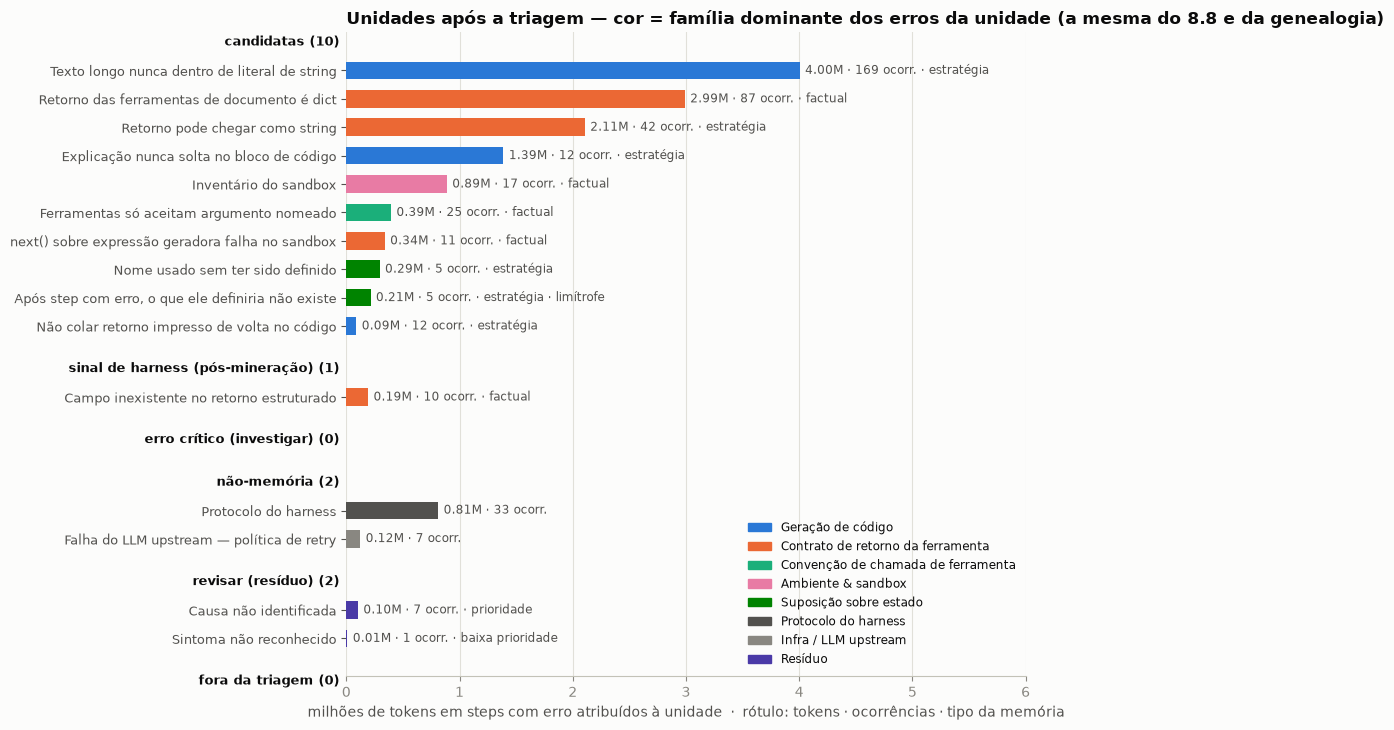

In [7]:
# 14.6 (era o 9.3 da esteira) · Gráfico — uma barra por unidade, agrupada pela decisão da triagem (as seções). Cor = a língua comum dos erros
# (COR_ERRO): a família dominante dos erros da unidade, a mesma do 8.8 e da genealogia. O tipo da memória (Hu et al.
# 2025, §4 — factual × estratégia) vai escrito no rótulo.
from matplotlib.patches import Patch
cat_uni = (EU.assign(cat=[categoria_do_erro(f, u) for f, u in zip(EU["familia"], EU["unidade"])])
             .groupby("unidade")["cat"].agg(lambda s: s.value_counts().index[0]))
TIPO_CURTO = {FACT: "factual", ESTR: "estratégia"}
GRUPO = {"candidato": "candidatas", SINAL_HARNESS: "sinal de harness (pós-mineração)",
         INVESTIGAR_CRITICO: "erro crítico (investigar)", "não-memória": "não-memória",
         REVISAR_PRIORIDADE: "revisar (resíduo)", REVISAR_BAIXA: "revisar (resíduo)",
         "fora: sem recorrência": "fora da triagem"}
T = TC   # a triagem consolidada (§14.2)
xmax = T["tokens"].max() / 1e6

fig, ax = plt.subplots(figsize=(10.5, 7.4))
pos, yticks, ylabels = 0.0, [], []
for grupo in ["candidatas", "sinal de harness (pós-mineração)", "erro crítico (investigar)", "não-memória",
              "revisar (resíduo)", "fora da triagem"]:
    sub = T[T["decisão"].map(GRUPO) == grupo].sort_values("tokens", ascending=False)
    ax.text(-0.01, pos, f"{grupo} ({len(sub)})", transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=9, fontweight="bold", color=INK)
    pos += 1
    for r in sub.to_dict("records"):
        ax.barh(pos, r["tokens"] / 1e6, color=cor(COR_ERRO, cat_uni[r["unidade"]]), height=0.62)
        nota = f" · {TIPO_CURTO[r['tipo']]}" if r["tipo"] in TIPO_CURTO else ""
        if r["nome"] in limitrofes:
            nota += " · limítrofe"
        elif grupo in ("fora da triagem", "revisar (resíduo)"):
            nota += " · " + r["decisão"].replace("fora: ", "").replace("revisar — ", "")
        ax.text(r["tokens"] / 1e6 + xmax * 0.012, pos, f"{r['tokens'] / 1e6:.2f}M · {r['ocorrências']} ocorr.{nota}",
                va="center", color=INK2, fontsize=8.5)
        yticks.append(pos); ylabels.append(r["nome"])
        pos += 1
    pos += 0.5

ax.set_yticks(yticks, ylabels, fontsize=9)
ax.invert_yaxis()
style_ax(ax)
ax.set_xlim(0, xmax * 1.5)
ax.set_title("Unidades após a triagem — cor = família dominante dos erros da unidade (a mesma do 8.8 e da genealogia)")
ax.set_xlabel("milhões de tokens em steps com erro atribuídos à unidade  ·  rótulo: tokens · ocorrências · tipo da memória")
ax.legend(handles=[Patch(color=cor(COR_ERRO, c), label=c) for c in COR_ERRO if c in set(cat_uni[T["unidade"]])],
          loc="lower right", fontsize=8.5, frameon=False)
plt.tight_layout(); plt.show()

## 14.7 · Candidatura por papel — a régua da triagem dentro de cada papel

*Era o 9.4 da esteira.* A §14.2 decide a candidatura da unidade **na base inteira**; aqui a mesma régua (≥3 execuções e
≥2 meses, sobre ocorrências) roda **dentro de cada papel** — a candidatura *scoped*, para uma memória escrita por papel —,
agora com os **dois canais** (`triagem_por_papel(..., silenciosas=)`): ocorrências, execuções e meses do papel contam a
união. Na célula, o nº é de **erros visíveis**; `+n` são as ocorrências silenciosas da unidade naquele papel. **Cor
cheia** = candidata no papel (cor = família dominante dos erros da unidade); **cinza** = ocorre no papel sem se repetir
nele; **vazio** = não ocorre. Plataforma e resíduo ficam fora por desenho. Mesmo corte do 8.8 da esteira (papéis com ≥5
erros). Uma unidade pode ser candidata no papel sem ser candidata global, e vice-versa — o cruzamento é a §14.8.

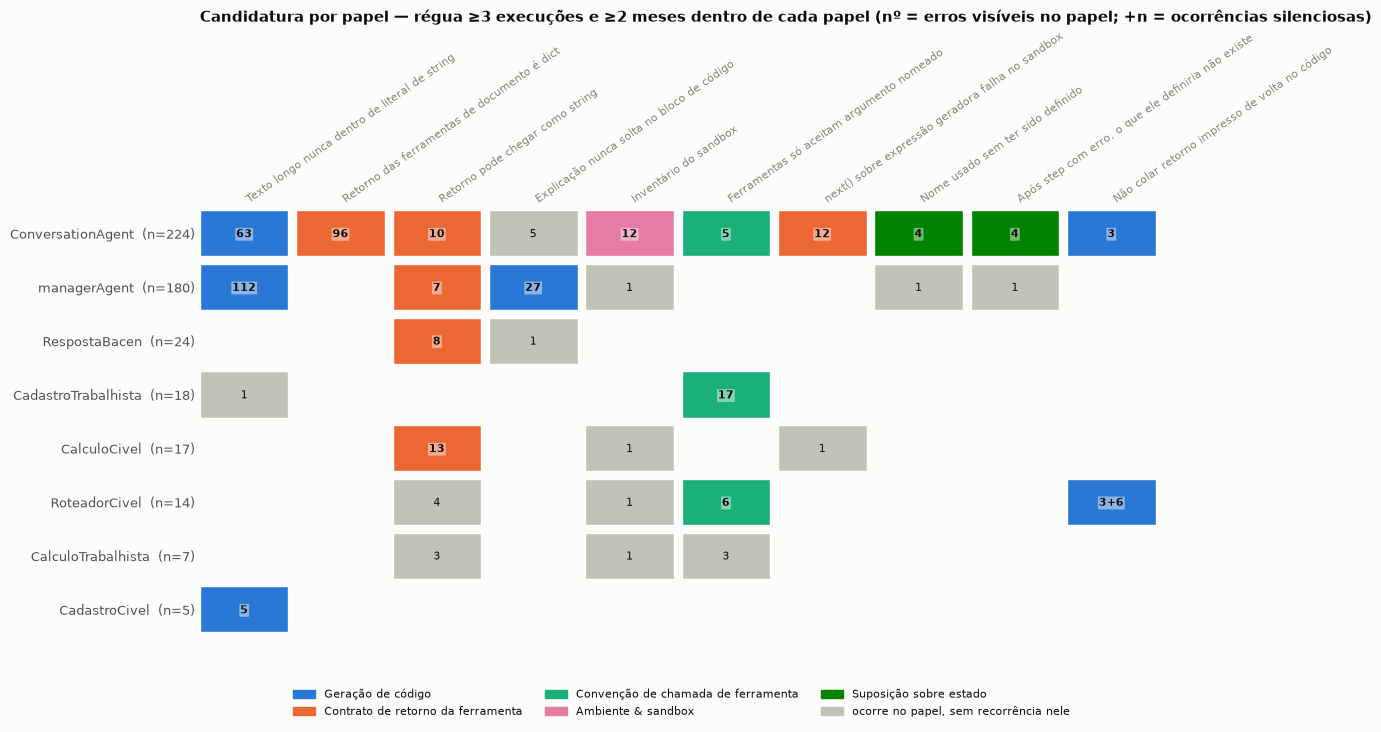

células (papel × unidade) candidatas: 18 de 31 com erro


,role,nome,tipo,decisão,ocorrências,ocorrências visíveis,ocorrências silenciosas,erros,execuções,meses,tokens
0,CadastroCivel,Texto longo nunca dentro de literal de string,experiencial · estratégia,candidato,5,5,0,5,5,2,26162
1,CadastroTrabalhista,Ferramentas só aceitam argumento nomeado,factual · ambiente,candidato,11,11,0,17,9,3,73489
3,CalculoCivel,Retorno pode chegar como string,experiencial · estratégia,candidato,11,11,0,13,8,2,1283706
9,ConversationAgent,Retorno das ferramentas de documento é dict,factual · ambiente,candidato,87,87,0,96,87,8,2989426
10,ConversationAgent,Texto longo nunca dentro de literal de string,experiencial · estratégia,candidato,59,59,0,63,55,7,2359387
11,ConversationAgent,Inventário do sandbox,factual · ambiente,candidato,12,12,0,12,12,6,411942
12,ConversationAgent,Retorno pode chegar como string,experiencial · estratégia,candidato,9,9,0,10,9,3,350253
13,ConversationAgent,next() sobre expressão geradora falha no sandbox,factual · ambiente,candidato,10,10,0,12,10,8,296913
14,ConversationAgent,Nome usado sem ter sido definido,experiencial · estratégia,candidato,4,4,0,4,4,3,285096
15,ConversationAgent,"Após step com erro, o que ele definiria não ex...",experiencial · estratégia,candidato,4,4,0,4,4,3,193518


In [8]:
# 14.7 (era o 9.4 da esteira) · Matriz papel × unidade com a régua da triagem DENTRO do papel (triagem_por_papel, base_pipeline).
T4 = triagem_por_papel(EU, silenciosas=OS)
papeis94 = list(EU["role"].value_counts()[lambda s: s >= 5].index)   # mesmo corte do 8.8
uni94 = [u for u in T["unidade"] if UNI[u][1] in (FACT, ESTR) and destino_mineracao(u) != "harness"]  # ordem do 14.6; sem o sinal de harness
tab94 = (T4.pivot_table(index="role", columns="unidade", values="erros", aggfunc="sum")
           .reindex(index=papeis94, columns=uni94))
dec94 = (T4.pivot_table(index="role", columns="unidade", values="decisão", aggfunc="first")
           .reindex_like(tab94))
sil94 = (T4.pivot_table(index="role", columns="unidade", values="ocorrências silenciosas", aggfunc="sum")
           .reindex_like(tab94).fillna(0))
# sanidade: a matriz fecha com o EU nas unidades elegíveis dos papéis exibidos
assert int(tab94.sum().sum()) == len(EU[EU["unidade"].isin(uni94) & EU["role"].isin(papeis94)])

n_erros_papel = EU[EU["role"].isin(papeis94)].groupby("role").size()
fig, ax = plt.subplots(figsize=(13.5, 0.62 * len(papeis94) + 2.6))
for i, papel in enumerate(papeis94):
    for j, u in enumerate(uni94):
        v = tab94.loc[papel, u]
        if pd.isna(v):
            continue
        cand = dec94.loc[papel, u] == "candidato"
        ax.add_patch(plt.Rectangle((j, i), 0.92, 0.86, edgecolor="white", linewidth=1,
                                   facecolor=cor(COR_ERRO, cat_uni[u]) if cand else BASE))
        ax.text(j + 0.46, i + 0.45, str(int(v)) + (f"+{int(sil94.loc[papel, u])}" if sil94.loc[papel, u] else ""), ha="center", va="center", fontsize=8, color=INK,
                fontweight="bold" if cand else "normal",
                bbox=dict(boxstyle="round,pad=0.08", facecolor="white", edgecolor="none",
                          alpha=0.45 if cand else 0.0))

ax.set_xticks([j + 0.46 for j in range(len(uni94))])
ax.set_xticklabels([UNI[u][0] for u in uni94], rotation=35, ha="left", fontsize=8)
ax.xaxis.set_ticks_position("top")
ax.set_yticks([i + 0.43 for i in range(len(papeis94))])
ax.set_yticklabels([f"{p}  (n={int(n_erros_papel[p])})" for p in papeis94], fontsize=9)
ax.set_xlim(0, len(uni94)); ax.set_ylim(len(papeis94), 0)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
fam_usadas = [c for c in COR_ERRO if c in set(cat_uni[u] for u in uni94)]
ax.legend(handles=[Patch(color=cor(COR_ERRO, c), label=c) for c in fam_usadas]
                + [Patch(color=BASE, label="ocorre no papel, sem recorrência nele")],
          loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=3, fontsize=8, frameon=False)
ax.set_title("Candidatura por papel — régua ≥3 execuções e ≥2 meses dentro de cada papel "
             "(nº = erros visíveis no papel; +n = ocorrências silenciosas)", fontsize=11, loc="left")
plt.tight_layout(); plt.show()
print(f"células (papel × unidade) candidatas: {int((dec94 == 'candidato').sum().sum())} de "
      f"{int(tab94.notna().sum().sum())} com erro")
display(T4[T4["decisão"] == "candidato"].drop(columns=["unidade"]))

## 14.8 · Global × papel — o que o recorte muda

*Era o 9.5 da esteira.* Cruzamento do veredito global (§14.2) com o do papel (§14.7), por (papel × unidade), na mesma
geometria da matriz. Quatro estados: **firme** — candidata nos dois; **herdada** — candidata global que não se repete
naquele papel; **revelada** — não passa na global mas passa no papel; **fora** — não passa em nenhuma. Abaixo, a
sensibilidade com a régua estrita (≥5 execuções e ≥3 meses), também com os dois canais — a "limítrofe por papel".

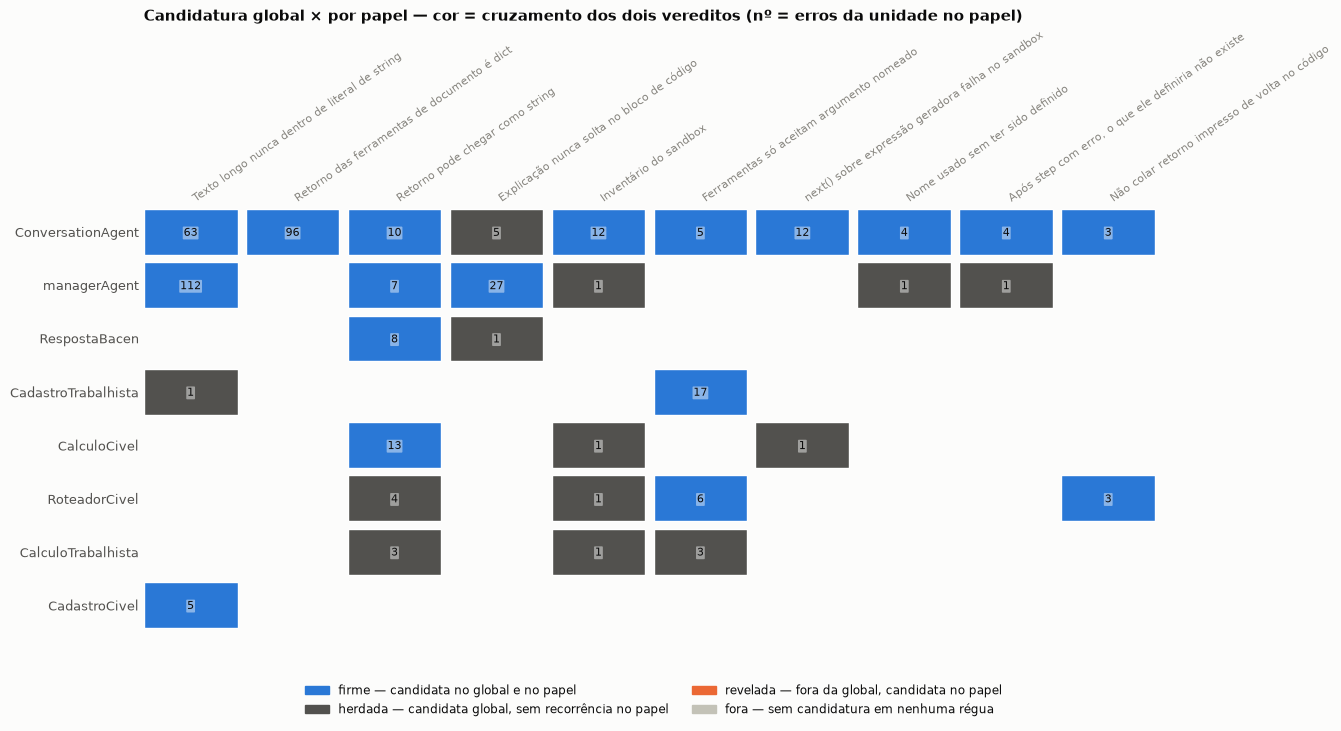

estados, células (papel × unidade) com erro: {'firme': 18, 'herdada': 13, 'revelada': 0, 'fora': 0}
reveladas: nenhuma
herdadas: ConversationAgent → Explicação nunca solta no bloco de código; managerAgent → Inventário do sandbox; managerAgent → Nome usado sem ter sido definido; managerAgent → Após step com erro, o que ele definiria não existe; RespostaBacen → Explicação nunca solta no bloco de código; CadastroTrabalhista → Texto longo nunca dentro de literal de string; CalculoCivel → Inventário do sandbox; CalculoCivel → next() sobre expressão geradora falha no sandbox; RoteadorCivel → Retorno pode chegar como string; RoteadorCivel → Inventário do sandbox; CalculoTrabalhista → Retorno pode chegar como string; CalculoTrabalhista → Inventário do sandbox; CalculoTrabalhista → Ferramentas só aceitam argumento nomeado
sensibilidade (≥5 execuções, ≥3 meses): 7 de 18 células candidatas deixam de ser — a limítrofe por papel


In [9]:
# 14.8 (era o 9.5 da esteira) · Comparativo: veredito global (14.2) × veredito por papel (14.7), mesma matriz do 9.4.
cor95 = {"firme": BLUE, "herdada": INK2, "revelada": ORANGE, "fora": BASE}
rot95 = {"firme": "firme — candidata no global e no papel",
         "herdada": "herdada — candidata global, sem recorrência no papel",
         "revelada": "revelada — fora da global, candidata no papel",
         "fora": "fora — sem candidatura em nenhuma régua"}
glob_cand = set(T.loc[T["decisão"] == "candidato", "unidade"])
def estado95(u, dec_papel):
    g, p = u in glob_cand, dec_papel == "candidato"
    return ("firme" if p else "herdada") if g else ("revelada" if p else "fora")

resumo95 = {}
fig, ax = plt.subplots(figsize=(13.5, 0.62 * len(papeis94) + 2.6))
for i, papel in enumerate(papeis94):
    for j, u in enumerate(uni94):
        v = tab94.loc[papel, u]
        if pd.isna(v):
            continue
        est = estado95(u, dec94.loc[papel, u])
        resumo95[est] = resumo95.get(est, 0) + 1
        ax.add_patch(plt.Rectangle((j, i), 0.92, 0.86, facecolor=cor95[est], edgecolor="white", linewidth=1))
        ax.text(j + 0.46, i + 0.45, str(int(v)), ha="center", va="center", fontsize=8, color=INK,
                bbox=dict(boxstyle="round,pad=0.08", facecolor="white", edgecolor="none", alpha=0.45))

ax.set_xticks([j + 0.46 for j in range(len(uni94))])
ax.set_xticklabels([UNI[u][0] for u in uni94], rotation=35, ha="left", fontsize=8)
ax.xaxis.set_ticks_position("top")
ax.set_yticks([i + 0.43 for i in range(len(papeis94))])
ax.set_yticklabels([p for p in papeis94], fontsize=9)
ax.set_xlim(0, len(uni94)); ax.set_ylim(len(papeis94), 0)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
ax.legend(handles=[Patch(color=cor95[k], label=rot95[k]) for k in cor95],
          loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=2, fontsize=8.5, frameon=False)
ax.set_title("Candidatura global × por papel — cor = cruzamento dos dois vereditos (nº = erros da unidade no papel)",
             fontsize=11, loc="left")
plt.tight_layout(); plt.show()

print("estados, células (papel × unidade) com erro:", {k: resumo95.get(k, 0) for k in cor95})
for est in ("revelada", "herdada"):
    lst = [(p, UNI[u][0]) for p in papeis94 for u in uni94
           if not pd.isna(tab94.loc[p, u]) and estado95(u, dec94.loc[p, u]) == est]
    print(f"{est}s: " + ("; ".join(f"{p} → {n}" for p, n in lst) if lst else "nenhuma"))

# sensibilidade por papel, análoga à do 14.2: régua estrita ≥5 execuções e ≥3 meses
TS4 = triagem_por_papel(EU, 5, 3, silenciosas=OS)
d32 = T4.set_index(["role", "unidade"])["decisão"]
d53 = TS4.set_index(["role", "unidade"])["decisão"]
mudam = ((d32 == "candidato") & (d53.reindex(d32.index) != "candidato")).sum()
print(f"sensibilidade (≥5 execuções, ≥3 meses): {mudam} de {(d32 == 'candidato').sum()} células candidatas "
      "deixam de ser — a limítrofe por papel")

## 14.9 · Exportação

`resultados/candidatos_memoria.csv` — **a** triagem das unidades, uma linha por unidade, com as colunas por canal. Desde
o plano 4.2c (04/10) é gravado só aqui; a esteira não decide mais. O nome e o lugar são os de sempre (a genealogia, as
auditorias e a mineração o leem).

In [10]:
os.makedirs("resultados", exist_ok=True)
TC.to_csv(os.path.join("resultados", "candidatos_memoria.csv"), index=False)
velho = os.path.join("resultados", "triagem_consolidada.csv")   # o nome provisório do Ajuste 12, substituído
if os.path.exists(velho): os.remove(velho)
print(f"{len(TC)} unidades → resultados/candidatos_memoria.csv")

15 unidades → resultados/candidatos_memoria.csv
